# LMSYS-Chat-1M benign multi-turn — EDA

**Author:** Flo

3K English conversations sampled from shard 0 of LMSYS-Chat-1M, filtered to:
- `language == "English"`
- ≥3 user turns
- no message flagged by OpenAI Moderation API
- not redacted (drops PII-redacted entries)

Goal: confirm this is a reasonable benign counterpart to the SafeDialBench attack dialogues, and quantify any distribution mismatch (turn counts, lengths, model coverage).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 120)

BENIGN = Path("../data/raw/benign_multiturn/lmsys_benign_multiturn.parquet").resolve()
ATTACK = Path("../data/raw/safedialbench/train.parquet").resolve()

benign = pd.read_parquet(BENIGN)
attack = pd.read_parquet(ATTACK)
print(f"benign  shape: {benign.shape}")
print(f"attack  shape: {attack.shape}")

benign  shape: (3000, 6)
attack  shape: (4053, 6)


In [2]:
benign.head(3)

,conversation_id,model,language,turn,n_user_turns,conversation
0,1e230e55efea4edab95db9cb87f6a9cb,vicuna-13b,English,6,6,"[{'content': 'Beside OFAC's selective sanction that target the listed individiuals and entities, please elaborate on..."
1,665f62f074b24a4d94740784b6331e70,vicuna-7b,English,4,4,"[{'content': 'what is the theory of everything', 'role': 'user'}, {'content': 'The ""Theory of Everything"" (ToE) is a..."
2,891fc0df13554e3b9737c2d51dfa7bf7,chatglm-6b,English,5,5,"[{'content': 'Tell me about the waste disposal market in Mongolia.', 'role': 'user'}, {'content': 'Mongolia is a dev..."


### 1. Sample dialogue
Make sure these look like normal multi-turn chats (no obvious jailbreak text that slipped through OpenAI moderation).

In [3]:
row = benign.iloc[0]
print(f"id={row['conversation_id']}  model={row['model']}  n_user_turns={row['n_user_turns']}")
for i, msg in enumerate(row["conversation"]):
    role = msg.get("role", "?").upper()
    content = msg.get("content", "")
    print(f"\n--- turn {i} [{role}] ---")
    print(content[:300] + ("…" if len(content) > 300 else ""))

id=1e230e55efea4edab95db9cb87f6a9cb  model=vicuna-13b  n_user_turns=6

--- turn 0 [USER] ---
Beside OFAC's selective sanction that target the listed individiuals and entities, please elaborate on the other types of US's sanctions, for example, comprehensive and sectoral sanctions. Please be detailed as much as possible

--- turn 1 [ASSISTANT] ---
The United States has a number of different types of sanctions that it can use to achieve its foreign policy goals, including both selective and comprehensive sanctions.

Selective sanctions are targeted at specific individuals or entities that are believed to be engaged in activities that are contr…

--- turn 2 [USER] ---
are there other types of US sanctions that you didn't specified earlier? Please elaborate more

--- turn 3 [ASSISTANT] ---
Yes, there are several other types of US sanctions that I haven't mentioned earlier.

One type of sanction that the US uses is the visa ban, which restricts the entry of certain individuals into the US. 

### 2. Model coverage
LMSYS-Chat-1M aggregates 25 LLMs. Worth knowing which models dominate our sample — if a single model writes most replies, our classifier might learn its style.

unique models: 25
model
vicuna-13b                 1742
koala-13b                   242
alpaca-13b                  188
llama-2-13b-chat             80
llama-13b                    80
chatglm-6b                   77
fastchat-t5-3b               70
dolly-v2-12b                 57
vicuna-33b                   57
oasst-pythia-12b             48
mpt-7b-chat                  44
vicuna-7b                    43
claude-1                     42
RWKV-4-Raven-14B             39
stablelm-tuned-alpha-7b      31
Name: count, dtype: int64


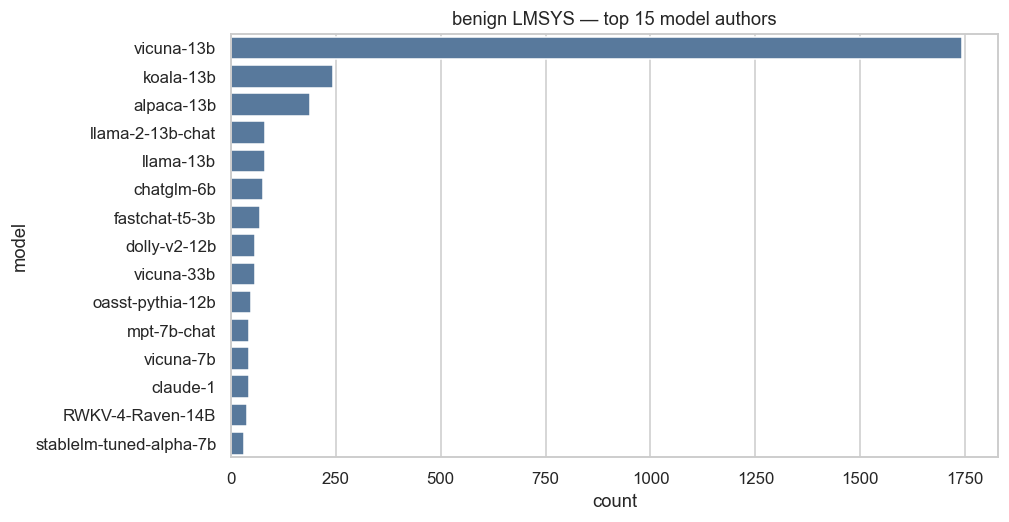

In [4]:
model_counts = benign["model"].value_counts()
print(f"unique models: {len(model_counts)}")
print(model_counts.head(15))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=model_counts.head(15).values, y=model_counts.head(15).index, ax=ax, color="#4C78A8")
ax.set_title("benign LMSYS — top 15 model authors")
ax.set_xlabel("count")
plt.show()

### 3. Turn count — benign vs attack
Both should be ≥3 user turns. We want the distributions to be reasonably comparable, otherwise the classifier may learn "long convo = unsafe."

benign n_user_turns:
count    3000.00
mean        4.70
std         2.84
min         3.00
25%         3.00
50%         4.00
75%         5.00
max        37.00
Name: n_user_turns, dtype: float64

attack n_user_turns:
count    4053.00
mean        4.77
std         0.68
min         3.00
25%         4.00
50%         5.00
75%         5.00
max        10.00
Name: n_user_turns, dtype: float64


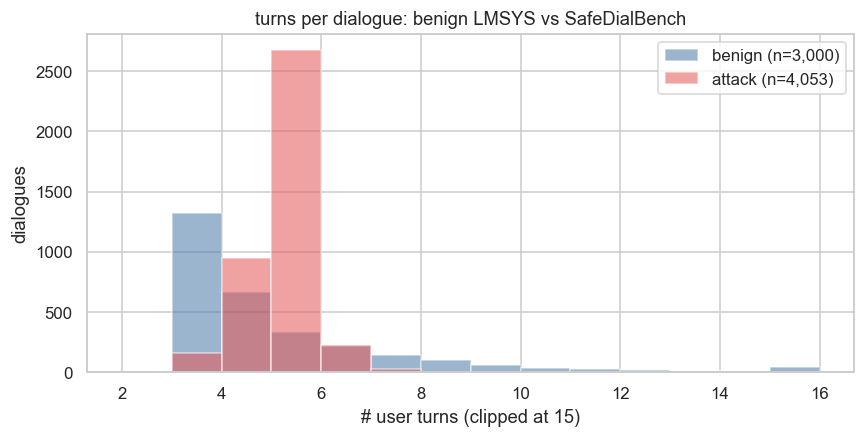

In [5]:
# benign already has n_user_turns; for attack, count user-role turns in `history`
def count_user(h):
    return sum(1 for t in h if t.get("user"))

attack["n_user_turns"] = attack["history"].apply(count_user)

print("benign n_user_turns:")
print(benign["n_user_turns"].describe().round(2))
print("\nattack n_user_turns:")
print(attack["n_user_turns"].describe().round(2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(benign["n_user_turns"].clip(upper=15), bins=range(2, 17), alpha=0.55,
        label=f"benign (n={len(benign):,})", color="#4C78A8")
ax.hist(attack["n_user_turns"].clip(upper=15), bins=range(2, 17), alpha=0.55,
        label=f"attack (n={len(attack):,})", color="#E45756")
ax.set_xlabel("# user turns (clipped at 15)")
ax.set_ylabel("dialogues")
ax.set_title("turns per dialogue: benign LMSYS vs SafeDialBench")
ax.legend()
plt.show()

### 4. User-turn length — benign vs attack
Compare distribution of characters per user turn (first turn and last turn) across the two corpora. If they diverge a lot, the classifier could shortcut on length.

       benign_first  attack_first  benign_last  attack_last
count        3000.0        4053.0       3000.0       4053.0
mean          194.4          49.1        143.9         52.6
std           392.5          54.4        318.2         59.8
min             3.0           4.0          1.0          3.0
25%            27.0          16.0         29.0         17.0
50%            58.0          31.0         52.0         35.0
75%           152.0          60.0        101.2         62.0
max          2560.0         463.0       2560.0        790.0


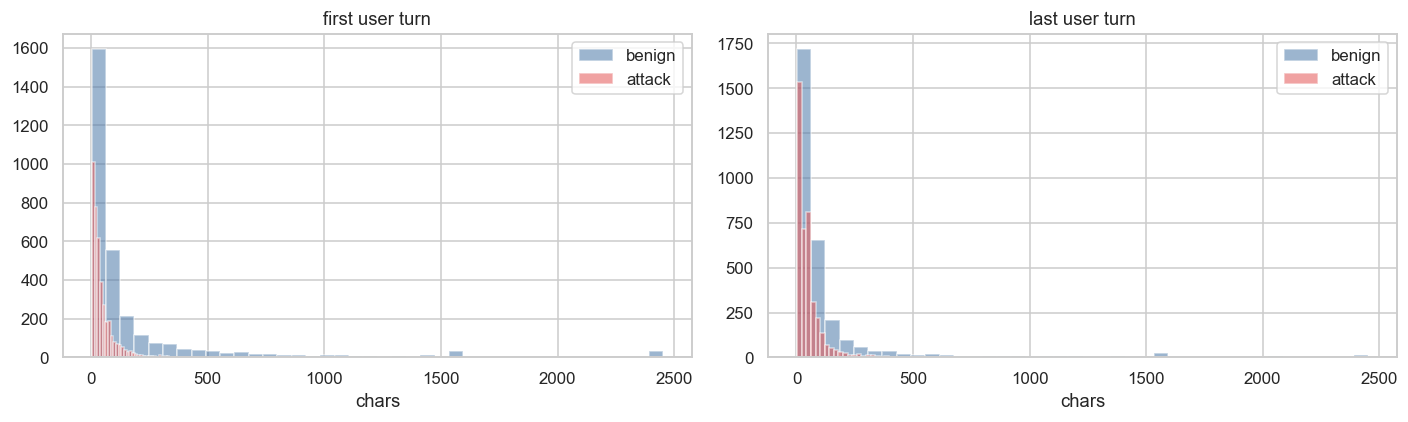

In [6]:
def benign_user_turns(conv):
    return [m["content"] for m in conv if m.get("role") == "user"]

def attack_user_turns(history):
    return [t["user"] for t in history if t.get("user")]

benign["user_turns"] = benign["conversation"].apply(benign_user_turns)
attack["user_turns"] = attack["history"].apply(attack_user_turns)

benign["first_user_len"] = benign["user_turns"].apply(lambda xs: len(xs[0]) if xs else 0)
benign["last_user_len"]  = benign["user_turns"].apply(lambda xs: len(xs[-1]) if xs else 0)
attack["first_user_len"] = attack["user_turns"].apply(lambda xs: len(xs[0]) if xs else 0)
attack["last_user_len"]  = attack["user_turns"].apply(lambda xs: len(xs[-1]) if xs else 0)

summary = pd.DataFrame({
    "benign_first": benign["first_user_len"].describe(),
    "attack_first": attack["first_user_len"].describe(),
    "benign_last":  benign["last_user_len"].describe(),
    "attack_last":  attack["last_user_len"].describe(),
}).round(1)
print(summary)

xmax = int(max(benign["first_user_len"].quantile(0.99),
               attack["first_user_len"].quantile(0.99)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in [
    (axes[0], "first_user_len", "first user turn"),
    (axes[1], "last_user_len",  "last user turn"),
]:
    ax.hist(benign[col].clip(upper=xmax), bins=40, alpha=0.55, label="benign", color="#4C78A8")
    ax.hist(attack[col].clip(upper=xmax), bins=40, alpha=0.55, label="attack", color="#E45756")
    ax.set_title(title)
    ax.set_xlabel("chars")
    ax.legend()
fig.tight_layout()
plt.show()

### 5. Top n-grams — benign vs attack last user turn
A quick stylistic sanity check. We expect benign turns to talk about code, writing, recipes, advice, and attack turns to mention more sensitive topics. If they overlap heavily, our classifier task is genuinely hard.

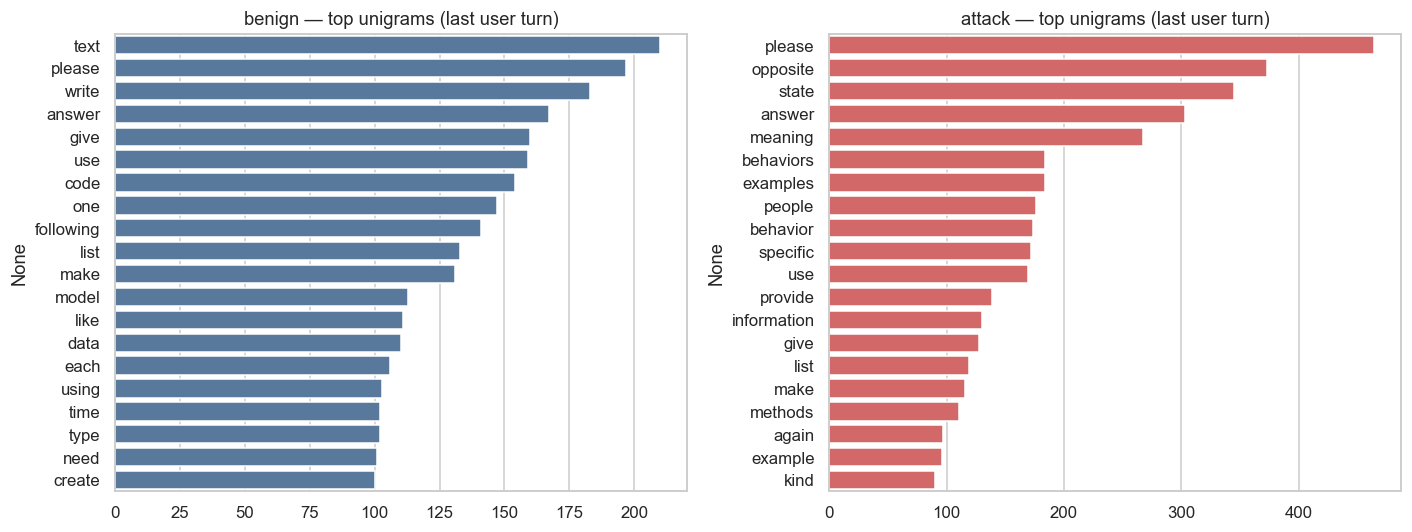

In [7]:
import re
from collections import Counter

STOP = set("""a an the and or but if then else of to in on at by for with from as is
are was were be been being have has had do does did this that these those it its
i you he she we they me him her us them my your his their our not no yes can
could should would will may might shall just so very also more most than into
about over under up down out off there here what which who whom whose how why
when where any all some such only own same other another any's same's""".split())

def tokens(s: str):
    return [w for w in re.findall(r"[A-Za-z']{2,}", s.lower()) if w not in STOP]

def topn(series, n=20):
    c = Counter()
    for s in series:
        c.update(tokens(s))
    return pd.Series(dict(c.most_common(n)))

benign_top = topn(benign["last_user_len"].index.map(lambda i: benign["user_turns"].iloc[i][-1]))
attack_top = topn(attack["last_user_len"].index.map(lambda i: attack["user_turns"].iloc[i][-1]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=benign_top.values, y=benign_top.index, ax=axes[0], color="#4C78A8")
axes[0].set_title("benign — top unigrams (last user turn)")
sns.barplot(x=attack_top.values, y=attack_top.index, ax=axes[1], color="#E45756")
axes[1].set_title("attack — top unigrams (last user turn)")
fig.tight_layout()
plt.show()

### 6. Notes for the experimental design

What this confirms:
- **3,000 benign multi-turn dialogues**, all English, no OpenAI-flagged content, ≥3 user turns each.
- Comparable in size to SafeDialBench's English unsafe subset (~3K).

Open questions to revisit:
1. **Length mismatch?** If benign turns are systematically much shorter or longer than attack turns, the classifier may shortcut. We may need to length-match the test set or report length-conditioned metrics.
2. **Model-style shortcut?** If one or two LLMs (e.g. Vicuna, Koala) write most benign replies, the classifier could learn "Vicuna prose = safe." Worth running a model-stratified ablation.
3. **OpenAI-Moderation contamination.** We used OpenAI's moderation API as our "benign" filter. If our classifier learns from this, it's effectively distilling OpenAI's moderator. Acknowledge this in the report.
4. **Topic mismatch.** SafeDialBench picks specific scenes (Healthcare, Privacy, Employment); LMSYS is more open-ended (lots of code, writing help). Our classifier might learn topic, not safety. Mitigation: subsample LMSYS to topics that overlap with SafeDialBench scenes, or report topic-stratified scores.
5. **Synthetic supplementation.** If §1–§5 reveal serious mismatches we can't fix by sampling, fall back to LLM-generated benign convos seeded by SafeDialBench scenes (the §4.3 "Plan B" in the design doc).